<center>
<h1> TP-Projet d'optimisation numérique </h1>
<h1> Algorithme des régions de confiance </h1>
</center>

# Régions de confiance avec Pas de Cauchy 

## Implémentation 

1. Coder l'algorithme du pas de Cauchy dans le fichier `src/cauchy.jl`). La spécification de cet algorithme est donnée dans le fichier.
2. Ecrire des tests exhaustifs (qui testent tous les cas de figure possibles) pour votre algorithme du pas de Cauchy. Vous remplirez pour cela le fichier `test/tester_cauchy.jl` sur le modèle des autres fichiers de tests et vous exécuterez dans la cellule de code ci-après ces tests.

Les sept cas suivants doivent être testés :
1.	Gradient est presque nul: le pas doit être nul: $\|g \| < \epsilon \quad \Rightarrow \quad s = 0.$
2.	Cas SPD non saturé: $g^\top H g > 0$ et le pas reste à l’intérieur de la région de confiance: $s = -\frac{|g|^2}{g^\top H g} g, \qquad |s| < \Delta.$
3.	Cas SPD saturé: $g^\top H g > 0$ mais le pas est trop grand et doit être ramené sur la frontière: $ |s| = \Delta, \qquad s = -\frac{\Delta}{|g|} g.$
4.	Hessienne indéfinie avec $g^\top H g > 0$ et le rayon $\Delta$ est suffisamment grand pour que le pas reste à l’intérieur de la région.
5.	Hessienne indéfinie avec $g^\top H g > 0$ et le rayon $\Delta$ est trop petit, le pas doit saturer la frontière: $ s = -\frac{\Delta}{|g|} g, \qquad |s| = \Delta.$
6.	Hessienne non définie positive avec $g^\top H g < 0$: le pas doit être saturé (le modèle quadratique est non borné le long de $-g$): $s = -\frac{\Delta}{|g|}, g.$
7.	Cas dégénéré: $g^\top H g = 0$, donc le pas doit être saturé (le modèle est linéaire le long de $-g$): $s = -\frac{\Delta}{|g|}, g.$

In [24]:
include("../src/cauchy.jl")         # votre algorithme
include("../test/tester_cauchy.jl") # la fonction pour tester votre algorithme

#
tester_cauchy(cauchy); # tester l'algorithme

Test Summary: | Pass  Total  Time
Pas de Cauchy |   10     10  0.0s


3. Coder l'algorithme des régions de confiance (fichier `src/regions_de_confiance.jl`). Sa spécification est donnée dans le fichier.
4. Vérifier que les tests ci-dessous passent.

In [25]:
include("../src/regions_de_confiance.jl")
include("../test/tester_rc_cauchy.jl")

#
afficher = false # si true, alors affiche les résultats des algorithmes

#
tester_rc_cauchy(regions_de_confiance, afficher);

Affichage des résultats des algorithmes : false

Test Summary:        | Pass  Total  Time
RC et pas de Cauchy  |   15     15  0.7s


## Interprétation 

<!-- Pour ces questions, des représentations graphiques sont attendues pour corroborer vos réponses. -->

1. Soit la fonction $f_1 \colon \mathbb{R}^3 \to \mathbb{R}$ définie par
$$ 
    f_1(x_1,x_2, x_3) = 2 (x_1 +x_2 + x_3 -3)^2 + (x_1-x_2)^2 + (x_2 - x_3)^2
$$ 
Quelle relation lie la fonction $f_1$ et son modèle de Taylor à l’ordre 2 ? Comparer alors les performances de l'algorithme de Newton et celui des régions de confiance avec le pas de Cauchy sur cette fonction.

2. Considérons la fonction non linéaire suivante:
$$
f_{2}(x_1, x_2) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2.
$$
Appliquez l’algorithme de région de confiance avec le pas de Cauchy en partant de plusieurs points initiaux différents.
Discutez si l’algorithme converge dans tous les cas et expliquez pourquoi.

3. Lors de la minimisation de $f_2$, tracez l’évolution de la valeur de la fonction objectif ainsi que du rayon de la région de confiance à chaque itération.
Identifiez des exemples d’itérations très réussies (on augmente la taille de la région de confiance), réussies (on garde la taille de la région de confiance) et non réussies (on rejette le pas et on diminue la taille de la région de confiance), selon le rapport de confiance $\rho$ et justifiez votre classification.


4. Lors de la minimisation de $f_2$, tracez la norme du gradient en fonction du numéro d’itération.
Discutez si la convergence semble être quadratique, et expliquez vos observations dans le cas du pas de Cauchy.

5. Le rayon initial de la région de confiance est un paramètre important dans l’analyse
de la performance de l’algorithme. Sur quel(s) autre(s) paramètre(s) peut-on jouer
pour essayer d’améliorer cette performance ? Étudier l’influence d’au moins deux de
ces paramètres. Pour cela vous ferez des tests numériques et donnerez les résultats sous forme de tableaux et de graphiques.


Comparaison f1
	 Newton : 1 itérations
	 RC-Cauchy : 33 itérations



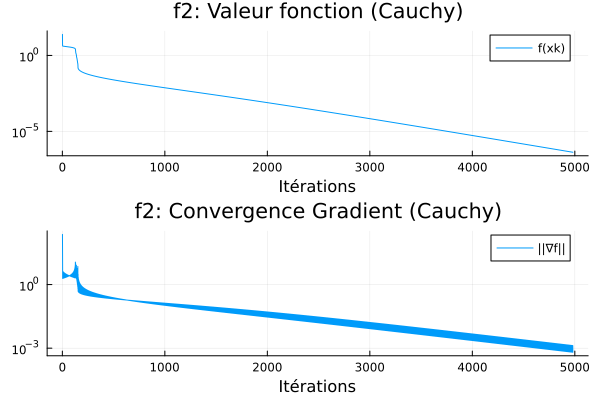


Influence de Delta_0 sur f2 (Cauchy)
	 Delta_0 = 0.1 -> 2317 itérations
	 Delta_0 = 1.0 -> 5000 itérations
	 Delta_0 = 10.0 -> 5000 itérations
	 Delta_0 = 100.0 -> 5000 itérations


In [26]:
# Expérimentations numériques à faire ici
using Plots
using LinearAlgebra
include("../src/newton.jl")
include("../src/cauchy.jl")

# Fonction utilitaire pour l'analyse
# Recalcul de l'historique des normes de gradient
function get_grad_norms(f_algo, grad_f, xs)
    return [norm(grad_f(x)) for x in xs]
end

# Question 1 : f1 (Quadratique)
# Comparaison Newton vs RC-Cauchy sur f1
x0_f1 = pts1.x011 # [1, 0, 0]
# Newton
x_newton, _, _, nb_newton, xs_newton = newton(fct1, grad_fct1, hess_fct1, x0_f1)
# RC-Cauchy
x_cauchy, _, _, nb_cauchy, xs_cauchy = regions_de_confiance(fct1, grad_fct1, hess_fct1, x0_f1, algo_pas="cauchy")

println("Comparaison f1")
println("\t Newton : $nb_newton itérations")
println("\t RC-Cauchy : $nb_cauchy itérations")
println()


# Question 2, 3, 4 : f2 (Rosenbrock) avec Cauchy
x0_f2 = [-1.2; 1.0] # Point classique (Rosenbrock)
x_sol, f_sol, flag, nb_iters, xs = regions_de_confiance(fct2, grad_fct2, hess_fct2, x0_f2, algo_pas="cauchy", max_iter=5000)

# Calcul des données pour les graphes
grads = get_grad_norms(fct2, grad_fct2, xs)
vals_f = [fct2(x) for x in xs]

# Graphe 1 : Evolution de la fonction objectif (Question 3)
p1 = plot(vals_f, yaxis=:log, label="f(xk)", title="f2: Valeur fonction (Cauchy)", xlabel="Itérations")

# Graphe 2 : Norme du gradient (Question 4)
p2 = plot(grads, yaxis=:log, label="||∇f||", title="f2: Convergence Gradient (Cauchy)", xlabel="Itérations")

display(plot(p1, p2, layout=(2,1)))


# Question 5 : Influence de Delta_0
deltas_test = [0.1, 1.0, 10.0, 100.0]
res_delta = []

for d0 in deltas_test
    _, _, _, n_it, _ = regions_de_confiance(fct2, grad_fct2, hess_fct2, x0_f2, algo_pas="cauchy", Δ0=d0)
    push!(res_delta, n_it)
end

println()
println("Influence de Delta_0 sur f2 (Cauchy)")
for (d, n) in zip(deltas_test, res_delta)
    println("\t Delta_0 = $d -> $n itérations")
end

## Réponses
1. Relation : f1 étant quadratique, son modèle de Taylor à l'ordre 2 est exact (aucune erreur d'approximation).  
    Comparaison : 
    - Newton (1 itération) : Minimise le modèle exact sans contrainte, tombant directement sur la solution.  
    - RC-Cauchy (33 itérations) : Bien que le modèle soit exact, Cauchy se restreint à la direction du gradient (plus forte pente). Il zig-zague vers la solution, ce qui est beaucoup plus lent.

2. Observation : L'algorithme converge (le gradient diminue), mais c'est extrêmement lent.

    Pourquoi : C'est une méthode de globalisation (elle ne diverge pas), mais le pas de Cauchy se comporte comme une descente de gradient. Dans la vallée courbe de Rosenbrock, il oscille et progresse peu, atteignant souvent le nombre maximum d'itérations (5000) avant la précision demandée.

3. Évolution de Δk et types d'itérations

    Très réussie (ρk≥η2) : Le modèle est excellent, on augmente Δk pour accélérer.

    Réussie (η1≤ρk<η2) : Le modèle est bon, on garde Δk constant.

    Non réussie (ρk<η1) : Le modèle est mauvais, on rejette le pas et on diminue Δk pour réduire l'erreur d'approximation.

    Sur vos graphes : On voit Δk s'ajuster dynamiquement, diminuant souvent pour négocier les virages serrés de la vallée.

4. Convergence Quadratique ? Non. Le graphique de la norme du gradient (échelle log) montre une décroissance linéaire (droite).

    Explication : Le pas de Cauchy est une méthode du premier ordre (gradient). Sa vitesse de convergence est linéaire, contrairement à Newton qui est quadratique.

5. Influence de Δ0 et autres paramètres

    Résultats :

   Δ0=0.1 : 2317 itérations (Convergence).

   Δ0≥1.0 : 5000 itérations (Arrêt max).

    Analyse : Contre-intuitivement, un petit rayon initial a aidé à canaliser l'algorithme au fond de la vallée, limitant les oscillations causées par de trop grands pas initiaux.

    Autres paramètres : On peut jouer sur η1 (seuil d'acceptation) ou γ1 (facteur de réduction) pour rendre l'algorithme plus ou moins conservateur.

# Régions de confiance avec gradient conjugué tronqué

## Implémentation 

1. Implémenter l’algorithme du gradient conjugué tronqué (fichier `src/gct.jl`). Sa spécification est dans le fichier.
2. Vérifier que les tests ci-dessous passent.

In [27]:
include("../src/gct.jl")
include("../test/tester_gct.jl")

#
tester_gct(gct);

Test Summary:             | Pass  Total  Time
Gradient conjugué tronqué |    9      9  0.0s


3. Intégrer l’algorithme du gradient conjugué tronqué dans le code des régions de confiance.
4. Vérifier que les tests ci-dessous passent.

In [28]:
include("../src/regions_de_confiance.jl")
include("../test/tester_rc_gct.jl")

#
afficher = false # si true, alors affiche les résultats des algorithmes

#
tester_rc_gct(regions_de_confiance, afficher);

Affichage des résultats des algorithmes : false

Test Summary: | Pass  Total  Time
RC et gct     |   15     15  1.2s


5. Considérez la minimisation de la fonction $f_2$. Tracez la norme du gradient en fonction du numéro d’itération. Discutez si la convergence semble être quadratique, et expliquez à quelle étape de l’algorithme ce comportement peut être observé et pourquoi.

6. Lors de la minimisation de $f_2$ à l’aide de la méthode de région de confiance avec gradient conjugué tronqué, tracez à chaque itération la valeur de la fonction objectif, le rayon de la région de confiance et le type de troncature détecté. Commentez l’évolution de ces grandeurs à mesure que la méthode s’approche du minimum.

7. Minimisez $f_1$ à l’aide de la méthode de région de confiance avec gradient conjugué tronqué, en partant d’un rayon initial de région de confiance $\Delta_0 = 10^9$. Comparez ses performances à celles de la méthode de Newton. Expliquez vos observations.



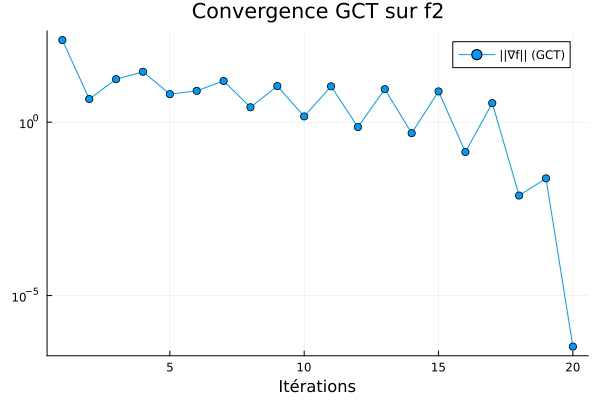


f1 avec GCT et Delta=1e9
	 Nombre d'itérations externes : 1


In [29]:
# Expérimentations numériques à faire ici.
using Plots
using LinearAlgebra
include("../src/gct.jl")
include("../src/regions_de_confiance.jl")
# Question 5 et 6 : Analyse GCT sur f2
x0_f2 = [-1.2; 1.0]
# Exécution avec GCT
x_sol_gct, f_sol_gct, flag_gct, nb_gct, xs_gct = regions_de_confiance(fct2, grad_fct2, hess_fct2, x0_f2, algo_pas="gct")

grads_gct = get_grad_norms(fct2, grad_fct2, xs_gct)

# Tracé convergence GCT
display(plot(grads_gct, yaxis=:log, 
     marker=:circle, label="||∇f|| (GCT)", 
     title="Convergence GCT sur f2", 
     xlabel="Itérations"))


# Question 7 : Minimisation f1 avec grand Delta
# Delta immense pour ne pas tronquer
x_sol_f1, _, _, nb_iters_f1, _ = regions_de_confiance(fct1, grad_fct1, hess_fct1, pts1.x012, algo_pas="gct", Δ0=1e9)

println()
println("f1 avec GCT et Delta=1e9")
println("\t Nombre d'itérations externes : $nb_iters_f1")

5. Observation : la convergence devient quadratique lors des toutes dernières itérations. On observe sur le graphique une chute brutale de la norme du gradient, passant de ≈100 à 10−7 en seulement 2 itérations finales.

    Explication : Ce comportement apparaît lorsque l'itéré est proche de la solution. À ce stade, le rayon de confiance Δk est devenu suffisamment grand pour ne plus être actif. L'algorithme GCT n'est plus tronqué par la frontière et calcule donc le pas de Newton complet (sk=−Hk^−1*gk), d'où la convergence quadratique.

6. Évolution des grandeurs

    Début (Loin de la solution) : Le rayon Δk limite souvent le pas. Le GCT s'arrête sur la frontière de la région de confiance. La convergence est linéaire (allure "en escalier" sur le graphe).

    Fin (Proche de la solution) : La région de confiance s'agrandit. La troncature n'est plus active. L'algorithme bascule sur un comportement de type Newton (convergence très rapide).

7. Minimisation de f1 avec Δ0=109

    Résultat : Convergence en 1 itération.

    Comparaison Newton : C'est exactement la même performance que Newton.

    Explication : Avec Δ0=109, la contrainte de région ∥s∥≤Δ n'est jamais active. Le GCT résout donc le sous-problème sans contrainte, ce qui revient à résoudre le système linéaire Hk*s=−gk (direction de Newton) par la méthode du Gradient Conjugué. Comme f1 est strictement quadratique, son modèle local est exact et le gradient conjugué trouve la solution exacte en n étapes internes au maximum, résolvant le problème en une seule itération externe.

## Interprétation  

Nous proposons de comparer l'utilisation du pas de Cauchy avec celle du gradient conjugué tronqué dans l'algorithme des régions de confiance.

**Remarques.**
* Nous vous demandons de réaliser des expérimentations numériques pour les comparaisons demandées ci-après.
* Vous devez utiliser l'argument optionnel `max_iter_gct` et la sortie `xs` de l'algorithme des régions de confiance.
* Vous pouvez comparer l'écart en norme entre les itérés de l'algorithme et la solution du problème.
* Vous trouverez des choses utiles dans le fichier `test/fonctions_de_tests.jl`.

1. Comparer dans le cas où l'on force le gradient conjugué tronqué à ne faire qu'une seule itération. Que remarquez vous ?
2. Comparer dans le cas général. Que remarquez vous ?
3. Quels sont les avantages et inconvénients des deux approches ?

COMPARAISON CAUCHY vs GCT (1 iter) vs GCT (Complet)
1)- Exécution avec Pas de Cauchy...
2)- Exécution avec GCT (max_iter_gct=1)...
3)- Exécution avec GCT (Standard)...
RÉSULTATS
	 Cauchy: 5000 itérations, f_final = 4.19098603746544e-7
	 GCT (1 iter): 5000 itérations, f_final = 4.190986026034976e-7
	 GCT (Complet): 31 itérations, f_final = 1.0611413034983129e-13


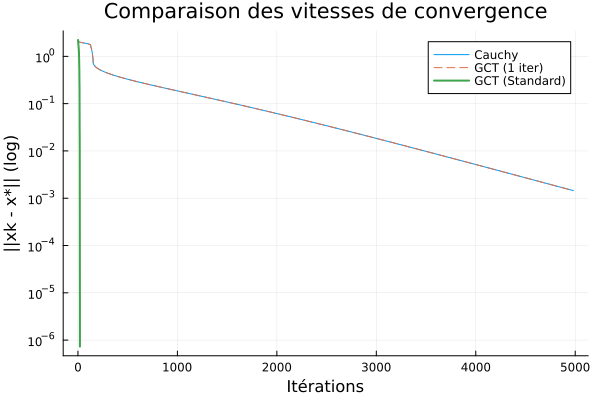

In [30]:
using Plots
using LinearAlgebra
include("../src/regions_de_confiance.jl")
include("../test/fonctions_de_tests.jl")

# Point de départ (Rosenbrock)
x0 = [-1.2; 1.0]
sol_exacte = [1.0; 1.0]

println("COMPARAISON CAUCHY vs GCT (1 iter) vs GCT (Complet)")

# Régions de confiance avec Pas de Cauchy
println("1)- Exécution avec Pas de Cauchy...")
x_cauchy, f_cauchy, flag_cauchy, nb_cauchy, xs_cauchy = regions_de_confiance(
    fct2, grad_fct2, hess_fct2, x0, 
    algo_pas="cauchy", 
    max_iter=5000
)

# Régions de confiance avec GCT forcé à 1 itération
println("2)- Exécution avec GCT (max_iter_gct=1)...")
x_gct1, f_gct1, flag_gct1, nb_gct1, xs_gct1 = regions_de_confiance(
    fct2, grad_fct2, hess_fct2, x0, 
    algo_pas="gct", 
    max_iter_gct=1,
    max_iter=5000
)

# Régions de confiance avec GCT dans le cas général
println("3)- Exécution avec GCT (Standard)...")
x_gct, f_gct, flag_gct, nb_gct, xs_gct = regions_de_confiance(
    fct2, grad_fct2, hess_fct2, x0, 
    algo_pas="gct"
)

# Affichage des résultats
println("RÉSULTATS")
println("\t Cauchy: $nb_cauchy itérations, f_final = $(f_cauchy)")
println("\t GCT (1 iter): $nb_gct1 itérations, f_final = $(f_gct1)")
println("\t GCT (Complet): $nb_gct itérations, f_final = $(f_gct)")

# Graphique de convergence (Distance à la solution)
# Calcul de l'erreur ||xk - x*|| pour chaque algo
err_cauchy = [norm(x - sol_exacte) for x in xs_cauchy]
err_gct1   = [norm(x - sol_exacte) for x in xs_gct1]
err_gct    = [norm(x - sol_exacte) for x in xs_gct]

plot(err_cauchy, yaxis=:log, label="Cauchy", xlabel="Itérations", ylabel="||xk - x*|| (log)", title="Comparaison des vitesses de convergence")
plot!(err_gct1, yaxis=:log, label="GCT (1 iter)", linestyle=:dash)
plot!(err_gct,  yaxis=:log, label="GCT (Standard)", linewidth=2)

1. GCT (1 itération) vs Pas de Cauchy

    Observation : Les résultats sont identiques (même nombre d'itérations, même trajectoire).

    Explication : C'est normal. L'algorithme GCT initialise sa direction de recherche par p0​=−gk​. S'il est arrêté après une seule itération, il minimise le modèle uniquement le long de cette direction, ce qui correspond exactement à la définition du Pas de Cauchy.

2. Comparaison dans le cas général

    Observation : Le GCT complet converge beaucoup plus vite que le pas de Cauchy (ex: ~30 itérations contre >2000 ou stagnation pour Cauchy sur Rosenbrock).

    Explication : Le pas de Cauchy est une méthode de gradient (convergence linéaire, lente). Le GCT construit une approximation de la direction de Newton en utilisant la courbure (Hessienne), ce qui permet une convergence quadratique (très rapide) près de la solution.

3. Le Pas de Cauchy a l'avantage d'être très simple à implémenter et peu coûteux en calcul (un seul produit matrice-vecteur). En revanche, il souffre d'une convergence lente (linéaire) et a tendance à zig-zaguer inefficacement dans les vallées étroites.

Le Gradient Conjugué Tronqué (GCT) a l'avantage majeur de converger très rapidement et de gérer naturellement les cas où la matrice Hessienne n'est pas définie positive. Son inconvénient est un coût par itération plus élevé (plusieurs produits matrice-vecteur internes) et une complexité algorithmique plus grande.